## TEST Baseline 1

모든 실험·개선·검증은 이 파일에서 진행한다.

| Step | 내용 |
|---|---|
| 1 | 파일 경로 확인 |
| 2 | 데이터 로드 |
| 3 |  |
| 4 |  |
| 5 |  |
| 6 |  |
| 7 |  |
| 8 | 스키마 검증 |
| 9 | 제출 CSV 저장 |

In [1]:
import os
import sys
import csv
import pandas as pd
from dataclasses import dataclass, field
from collections import Counter

## Step 1. 파일 경로 확인
모든 경로 내 파일이 실제로 존재하는지 확인한다.

In [2]:
@dataclass # __init__ 자동 생성, __post_init__ 자동 호출하는 데코레이터
class WindforceDataLoader:
    """# WINDFORCE 데이터 로드를 담당하는 클래스"""
    root: str = "/Users/ksydata/WINDFORCE"
    # 프로젝트 루트 경로 (기본값)
    root_train: str = field(init = False)
    # 학습 데이터 루트 경로, __post_init__에서 채워짐 (생성자 인자로 안 받음)
    root_test: str = field(init = False)                     
    # 평가 데이터 루트 경로, __post_init__에서 채워짐 (생성자 인자로 안 받음)
    encoding: str = "utf-8-sig"
    # "UTF-8 with BOM"("utf-8-sig")으로 csv 파일을 읽고 쓰기 위해 인코딩 설정

    _paths: dict = field(default_factory = dict, init = False)
    # 파일명 -> 경로 매핑 딕셔너리, 초기값은 빈 딕셔너리
    _cache: dict = field(default_factory = dict, init = False)
    # 파일명 -> 로딩된 DataFrame 캐시, 초기값은 빈 딕셔너리

    def __post_init__(self):
        """dataclass의 __init__ 실행 직후 자동 호출되는 메서드"""
        self.root_train = f"{self.root}/TRAIN"
        self.root_test = f"{self.root}/TEST"

        self._paths = {
        # 각 데이터 파일의 논리적 이름과 실제 경로를 매핑
            "ldaps_train": f"{self.root_train}/ldaps_train.csv",
            # LDAPS 기반 기상 예보 데이터로 각각 학습 기간과 평가 기간의 기상 예보 정보 포함
            # 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00 (약 1.5 km 공간해상도의 16개 격자에 대해 제공)

            "gfs_train": f"{self.root_train}/gfs_train.csv",
            # GFS 기반 기상 예보 데이터로 각각 학습 기간과 평가 기간의 기상 예보 정보 포함
            # 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00 (약 0.25도 공간해상도의 9개 격자에 대해 제공)

            "ldaps_test": f"{self.root_test}/ldaps_test.csv",
            # LDAPS 기반 기상 예보 데이터 (약 1.5 km 공간해상도의 16개 격자에 대해 제공)
            # 2025-01-01 01:00:00 ~ 2026-01-01 00:00:00

            "gfs_test": f"{self.root_test}/gfs_test.csv",
            # GFS 기반 기상 예보 데이터 (약 0.25도 공간해상도의 9개 격자에 대해 제공)
            # 2025-01-01 01:00:00 ~ 2026-01-01 00:00:00

            "train_labels": f"{self.root_train}/train_labels.csv",
            # 학습 기간의 KPX 그룹별 실제 발전량 데이터로 해당 값을 정답값으로 활용하여 모델 학습
            # 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00

            "scada_vestas_train": f"{self.root_train}/scada_vestas_train.csv",
            # VESTAS 제작사의 터빈의 학습 기간 SCADA 실측 데이터
            # 터빈 단위의 운전 및 발전 관련 실측 정보 포함

            "scada_unison_train": f"{self.root_train}/scada_unison_train.csv",
            # UNISON 제작사의 터빈의 학습 기간 SCADA 실측 데이터
            # 터빈 단위의 운전 및 발전 관련 실측 정보 포함

            "sample_submission": f"{self.root}/INFO/sample_submission.csv"
            # 참고용 sample 제출 양식 (총 8,760개 행으로 구성)
            # 특정 풍력단지(3개 그룹)의 향후 발전량을 예측하는 AI 모델을 통한
            # 평가 기간의 KPX 3그룹별 예측 발전량을 지정된 형식에 맞게 입력하여 제출

            # "submission_schema": f"{self.root}/submission.csv",
            # 제출용 sample 양식
        }

    def check_paths(self) -> dict[str, bool]:
        """모든 경로 존재 여부 확인 및 출력하는 메서드"""
        status = {}
        # 결과를 담을 빈 딕셔너리 초기화
        for name, path in self._paths.items():
            # _paths의 모든 (파일명, 경로) 쌍을 순회
            exists = os.path.exists(path) 
            # 해당 경로에 실제 파일이 존재하는지 확인
            status[name] = exists
            # 결과 딕셔너리에 존재 여부 저장
            print(f"{'✅' if exists else '❌'}  {name}: {path}")
        return status
        # 전체 파일의 존재 여부 딕셔너리 반환

    def load(self, name: str, force: bool = False, **kwargs) -> pd.DataFrame: 
        """개별 파일 로드 메서드 (캐싱 지원)"""
        if name not in self._paths:
        # 요청한 파일명이 _paths에 등록되지 않은 경우
            raise KeyError(f"'{name}'은 등록된 파일이 아닙니다. 사용 가능: {list(self._paths.keys())}")
            # 유효한 이름 목록과 함께 에러 발생
        if name in self._cache and not force:  
        # 이미 캐시에 있고 강제 재로딩이 아니면
            return self._cache[name]
            # 캐시된 DataFrame을 바로 반환 (재로딩 방지)

        df = pd.read_csv(self._paths[name], encoding = self.encoding, **kwargs)
        # 지정된 인코딩으로 CSV 파일 읽기
        self._cache[name] = df
        # 읽은 DataFrame을 캐시에 저장
        return df
        # 로딩한 DataFrame 반환

    def load_all(self, force: bool = False) -> dict[str, pd.DataFrame]:
        """전체 파일 로드 메서드"""
        for name in self._paths:
            try: 
            # 개별 파일 로딩 실패가 전체를 중단시키지 않도록 예외 처리
                self.load(name, force = force)
                # 해당 파일 로딩 (내부적으로 캐시에 저장됨)
                print(f"✅ {name}: shape={self._cache[name].shape}")
                # 성공 시 shape(행, 열) 정보 출력
            except Exception as e:
            # 로딩 중 에러 발생 시(파일 없음, 인코딩 오류 등)
                print(f"❌ {name}: {e}")
                # 어떤 파일에서 어떤 에러가 났는지 출력
        return self._cache
        # 지금까지 로딩된 모든 DataFrame 캐시 반환

    def summarize(self, name: str) -> None: 
        """컬럼 및 날짜 범위 요약하는 메서드"""
        df = self.load(name)
        # 해당 파일 로드(단, 캐시에 있으면 캐시 사용)
        print(f"\n[{name}] columns: {list(df.columns)}")
        # 파일명과 전체 컬럼 목록 출력

        date_cols = [c for c in df.columns if any(k in c.lower() for k in ["date", "time", "일시", "시간"])]  
        # 컬럼명에 날짜 관련 키워드가 포함된 컬럼만 추출
        for date_col in date_cols:
            # 추출된 날짜 관련 컬럼들을 순회
            try:
            # 날짜 파싱 실패(형식 오류 등)에 대비한 예외 처리
                parsed = pd.to_datetime(df[date_col])
                # 문자열 컬럼을 datetime 타입으로 변환
                print(f"  {date_col}: {parsed.min()} ~ {parsed.max()}")
                # 해당 컬럼의 최소~최대 날짜 범위 출력
            except Exception:
                # 변환 실패 시
                print(f"  {date_col}: 파싱 실패 (샘플: {df[date_col].iloc[0]})")
                # 실패했다는 메시지와 첫 번째 값 샘플 출력

    def __getitem__(self, name: str) -> pd.DataFrame:
        # loader["파일명"] 형태의 딕셔너리 접근 문법 지원
        return self.load(name)
        # load() 메서드를 그대로 호출하여 반환 (캐싱 로직 재사용)

## Step 2. 데이터 로드 및 구조 확인
- 풍력발전량 예측에서 입력으로 봐야 할 기상 변수는 무엇인가?
- 시간 단위 예측값 제출에서 실수하기 쉬운 포맷은 무엇인가?
- NMAE와 정산금획득률 중 어느 지표가 내 실험 로그에 먼저 들어가야 하는가?

In [3]:
loader = WindforceDataLoader()   
# 클래스 인스턴스 생성 (root 기본값 사용)
loader.check_paths()             
# 파일 존재 여부 먼저 확인

✅  ldaps_train: /Users/ksydata/WINDFORCE/TRAIN/ldaps_train.csv
✅  gfs_train: /Users/ksydata/WINDFORCE/TRAIN/gfs_train.csv
✅  ldaps_test: /Users/ksydata/WINDFORCE/TEST/ldaps_test.csv
✅  gfs_test: /Users/ksydata/WINDFORCE/TEST/gfs_test.csv
✅  train_labels: /Users/ksydata/WINDFORCE/TRAIN/train_labels.csv
✅  scada_vestas_train: /Users/ksydata/WINDFORCE/TRAIN/scada_vestas_train.csv
✅  scada_unison_train: /Users/ksydata/WINDFORCE/TRAIN/scada_unison_train.csv
✅  sample_submission: /Users/ksydata/WINDFORCE/INFO/sample_submission.csv


{'ldaps_train': True,
 'gfs_train': True,
 'ldaps_test': True,
 'gfs_test': True,
 'train_labels': True,
 'scada_vestas_train': True,
 'scada_unison_train': True,
 'sample_submission': True}

In [4]:
loader.load_all()                
# 전체 로딩 및 shape 출력

✅ ldaps_train: shape=(420864, 35)
✅ gfs_train: shape=(236736, 40)
✅ ldaps_test: shape=(140160, 35)
✅ gfs_test: shape=(78840, 40)
✅ train_labels: shape=(26304, 4)
✅ scada_vestas_train: shape=(157819, 37)
✅ scada_unison_train: shape=(105264, 16)
✅ sample_submission: shape=(8760, 5)


{'ldaps_train':            forecast_kst_dtm data_available_kst_dtm  grid_id  latitude  \
 0       2022-01-01 01:00:00    2021-12-31 13:00:00        1   37.3032   
 1       2022-01-01 01:00:00    2021-12-31 13:00:00        2   37.3027   
 2       2022-01-01 01:00:00    2021-12-31 13:00:00        3   37.3022   
 3       2022-01-01 01:00:00    2021-12-31 13:00:00        4   37.2899   
 4       2022-01-01 01:00:00    2021-12-31 13:00:00        5   37.2894   
 ...                     ...                    ...      ...       ...   
 420859  2025-01-01 00:00:00    2024-12-30 13:00:00       12   37.2745   
 420860  2025-01-01 00:00:00    2024-12-30 13:00:00       13   37.2740   
 420861  2025-01-01 00:00:00    2024-12-30 13:00:00       14   37.2617   
 420862  2025-01-01 00:00:00    2024-12-30 13:00:00       15   37.2612   
 420863  2025-01-01 00:00:00    2024-12-30 13:00:00       16   37.2607   
 
         longitude  heightAboveGround_10_10u  heightAboveGround_10_10v  \
 0        128.9443   

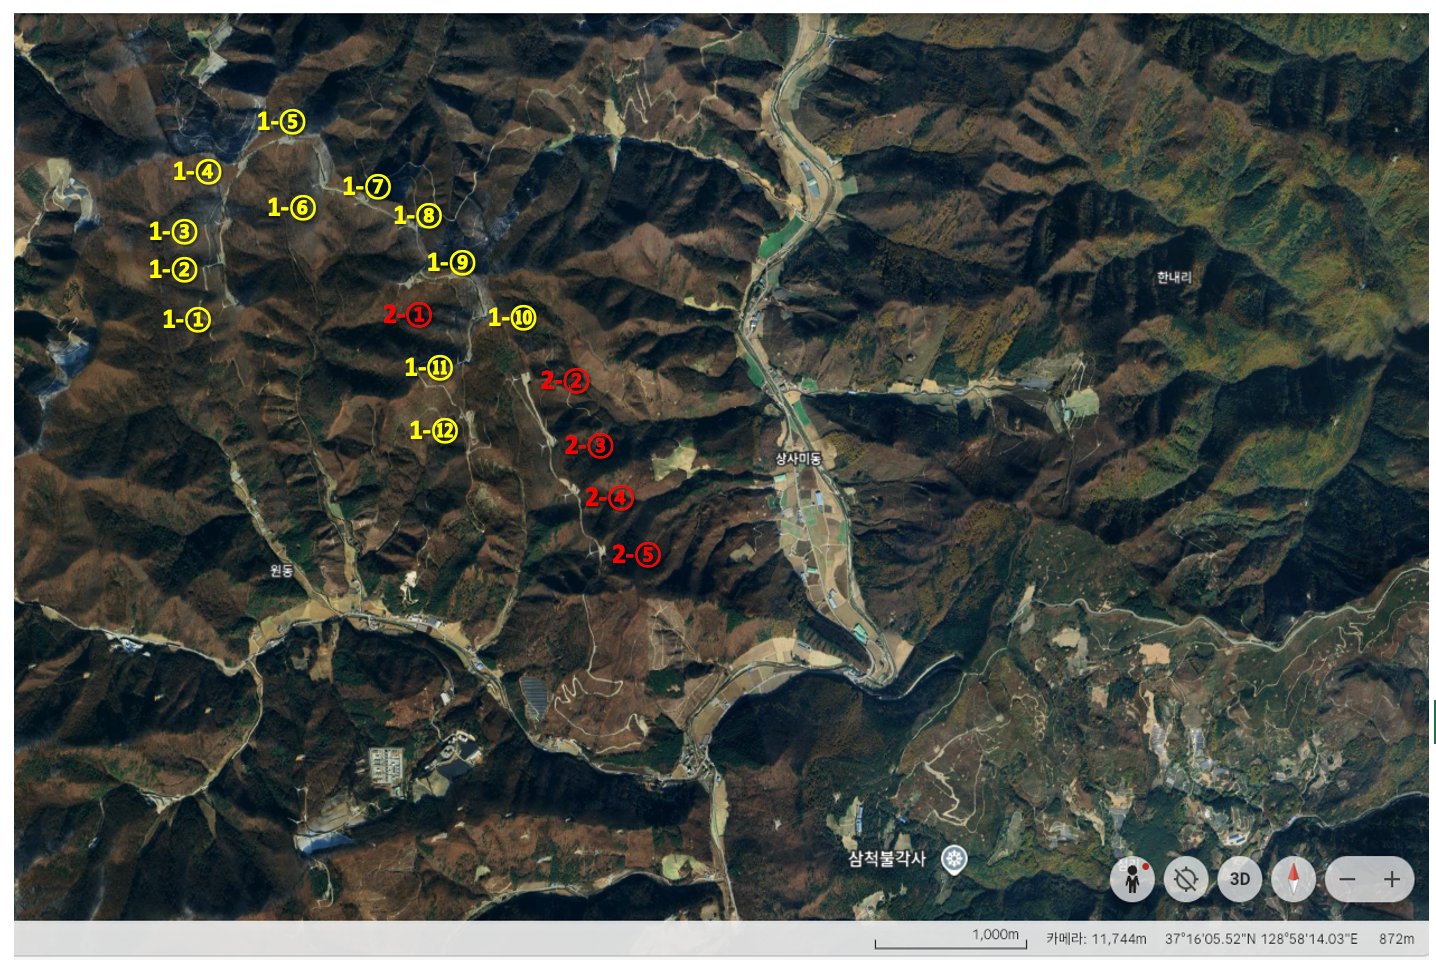

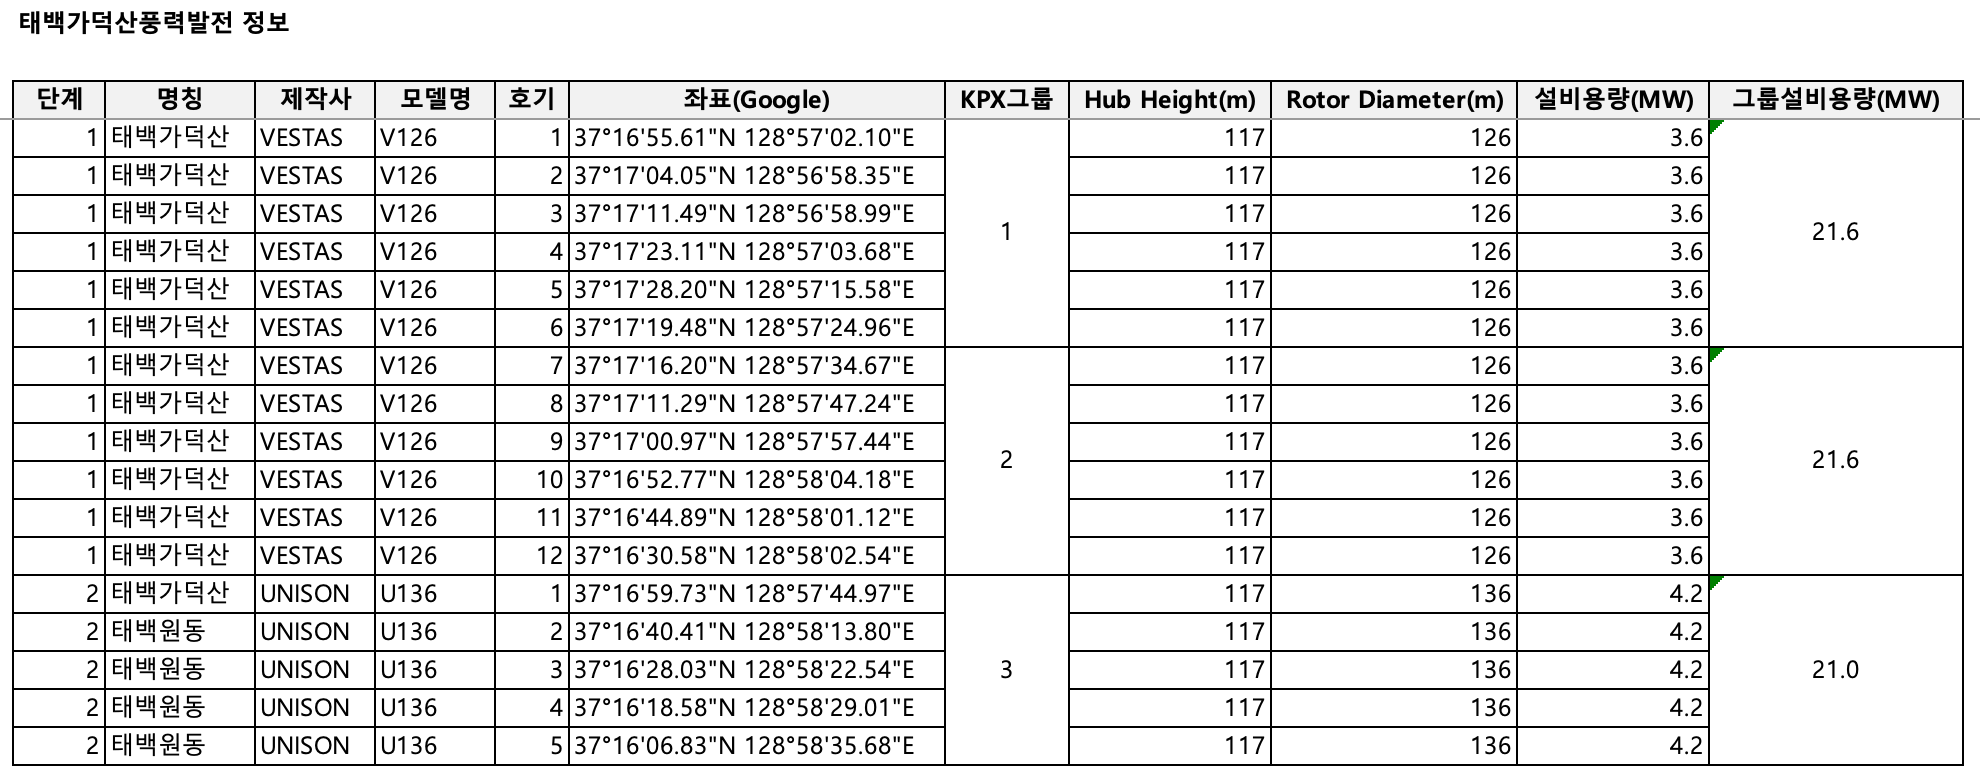

## Step 3. 분석 방향

1. 기초 이론 및 방법론 (Domain Foundation)
    - https://news.skecoplant.com/board/17696
2. 딥러닝 기반 모델링 (Deep Learning Architectures) 및 시계열 예측
    - http://journal.auric.kr/kiee/XmlViewer/f397619
    - https://kr.mathworks.com/company/user_stories/korea-institute-of-energy-research-develops-ai-based-predictive-maintenance-models-for-offshore-wind-power.html
3. 데이터 엔지니어링 및 특화 기법 (Advanced Feature Engineering)